#Introducción
En esta actividad se aplica el algoritmo de clusterización K-means, una técnica de Machine Learning no supervisado, cuyo objetivo es agrupar datos en diferentes conjuntos (clusters) en función de su similitud.

A diferencia de los modelos supervisados, en este caso no existe una variable objetivo (Y), sino que el algoritmo identifica patrones ocultos en los datos.

En este ejercicio se trabaja con un dataset de viviendas en California, utilizando variables geográficas y socioeconómicas para generar segmentos económicos.

#Objetivo del Notebook
Aplicar el algoritmo K-means para:

Agrupar datos en clusters
Identificar patrones en ingresos y ubicación geográfica
Interpretar los segmentos generados para posibles aplicaciones (como marketing)

#Carga de datos
Se importa la librería pandas y se carga el dataset de viviendas.
Este dataset contiene información sobre viviendas en California, incluyendo variables como:

Latitud

Longitud

Ingresos medios

Valor de las viviendas

In [44]:
import pandas as pd
datos = pd.read_csv("housing.csv")

#Exploración inicial del dataset
Se visualizan las primeras filas del dataset para comprender su estructura.
Esto permite identificar las columnas disponibles y validar que los datos se cargaron correctamente.

In [45]:
datos.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


#Visualización: mapa por valor de vivienda
Se genera un gráfico de dispersión utilizando seaborn, donde:

*   Eje X: latitud
*   Eje Y: longitud
*   Color: valor medio de las casas

Este gráfico permite observar la distribución geográfica del valor de las viviendas, funcionando como un mapa visual del dataset.

<Axes: xlabel='latitude', ylabel='longitude'>

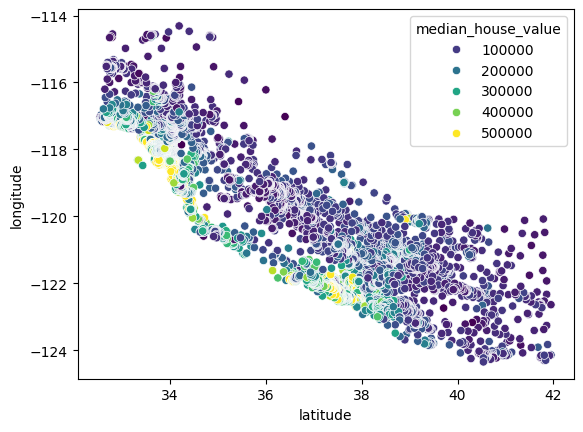

In [46]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_house_value", palette="viridis")

#Visualización: mapa por ingresos
Se crea una segunda visualización, ahora basada en los ingresos medios.

En este caso:

El color representa el nivel de ingresos

El tamaño de los puntos también refleja los ingresos

Esto permite identificar zonas con diferentes niveles socioeconómicos, aunque aún no están claramente segmentadas.

<Axes: xlabel='latitude', ylabel='longitude'>

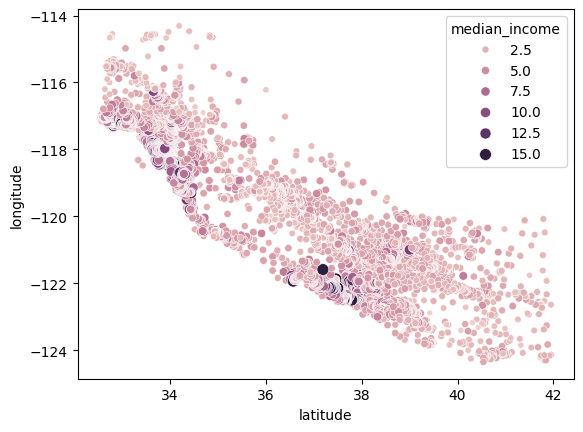

In [47]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_income",
               size="median_income")

#Selección de variables para el modelo
Se seleccionan únicamente las variables relevantes para la clusterización:

Según el enfoque del ejercicio (y el video), se utilizan:

Coordenadas geográficas (latitud y longitud)
Ingresos medios

Esto permite crear clusters basados en ubicación + nivel económico.

In [48]:
datos.loc[:, ["latitude", "longitude", "median_income"]]

,latitude,longitude,median_income
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462
...,...,...,...
20635,39.48,-121.09,1.5603
20636,39.49,-121.21,2.5568
20637,39.43,-121.22,1.7000
20638,39.43,-121.32,1.8672


#Aplicación del modelo K-means
Se importa el algoritmo K-means y se define el conjunto de datos de entrada.

**Explicación:**

KMeans(n_clusters=6): se define el número de clusters (6 grupos)

fit_predict(x):
Entrena el modelo
Asigna cada registro a un cluster

A diferencia de modelos supervisados, aquí no se utiliza variable Y.

In [49]:
from sklearn.cluster import KMeans
x = datos.loc[:, ["latitude", "longitude", "median_income"]]
modelo = KMeans(n_clusters=6)
predicciones = modelo.fit_predict(x)

#Dimensión de las predicciones
Se verifica la cantidad de predicciones generadas.

Esto debe coincidir con el número de registros del dataset, ya que cada dato es asignado a un cluster.

In [50]:
predicciones.shape

(20640,)

#Creación de nueva variable (segmento económico)
Se agrega una nueva columna al dataset con los clusters generados.

Cada registro ahora tiene asignado un número que representa su grupo o segmento.


In [51]:
x["segmento_econmico"] = predicciones

#Visualización del nuevo dataset
Se puede observar el dataset con la nueva columna segmento_econmico, que representa la clasificación generada por K-means.

In [52]:
x

,latitude,longitude,median_income,segmento_econmico
0,37.88,-122.23,8.3252,0
1,37.86,-122.22,8.3014,0
2,37.85,-122.24,7.2574,0
3,37.85,-122.25,5.6431,0
4,37.85,-122.25,3.8462,3
...,...,...,...,...
20635,39.48,-121.09,1.5603,3
20636,39.49,-121.21,2.5568,3
20637,39.43,-121.22,1.7000,3
20638,39.43,-121.32,1.8672,3


#Distribución de los clusters
Se analiza cuántos datos pertenecen a cada cluster.

Esto permite identificar:

*   Qué clusters son más grandes
*   Qué clusters son más pequeños

Generalmente, los grupos más pequeños pueden representar segmentos más específicos (por ejemplo, ingresos altos).

In [53]:
x["segmento_econmico"].value_counts()

,count
segmento_econmico,
3,5482
2,5174
4,4752
0,3022
1,1845
5,365


#Visualización de clusters
Se genera una gráfica para visualizar los segmentos en el mapa.

Ahora cada color representa un cluster diferente, lo que permite observar claramente la segmentación geográfica.

<Axes: xlabel='latitude', ylabel='longitude'>

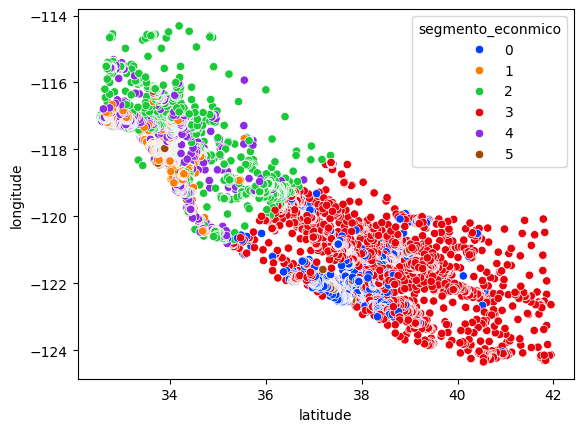

In [54]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=x, hue="segmento_econmico", palette="bright")

#Conteo de segmentos
Se muestra la cantidad de registros por cluster de forma gráfica.

Esto facilita comparar visualmente el tamaño de cada grupo.

<Axes: xlabel='segmento_econmico', ylabel='count'>

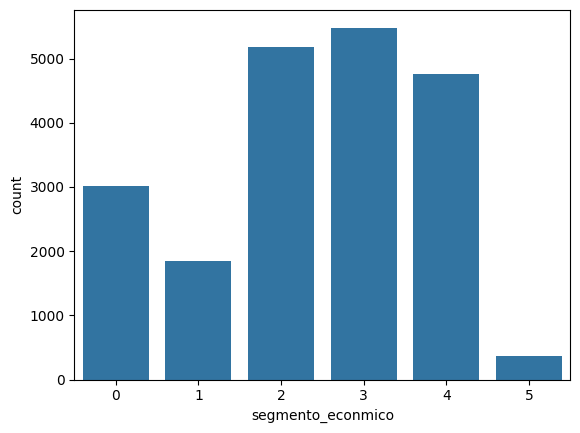

In [56]:
sb.countplot(x="segmento_econmico", data=x)

#Análisis de ingresos por cluster
Se calcula el ingreso promedio por cada segmento.

Este paso es clave para interpretar los clusters, ya que permite identificar:

*   Qué grupo tiene mayores ingresos
*   Qué grupo tiene menores ingresos

In [59]:
x.groupby(["segmento_econmico"])["median_income"].mean()

,median_income
segmento_econmico,
0,5.393045
1,6.579160
2,2.380652
3,2.737185
4,4.195443
5,11.492674


#Conclusiones
*   El algoritmo K-means permitió segmentar los datos en 6 grupos basados en ubicación e ingresos.

*   Se identificaron patrones geográficos asociados al nivel socioeconómico.
*   Los clusters permiten clasificar regiones en distintos niveles económicos.
*   Este tipo de análisis es útil para:
      *    Marketing segmentado
      *    Planeación de servicios
      *    Estudios socioeconómicos

#Interpretación de los segmentos
*   Cada número en segmento_econmico representa un grupo con características similares.
*   Los clusters con menor cantidad de datos suelen corresponder a ingresos más altos.
*   Los clusters más grandes suelen representar ingresos medios o bajos.
*   El análisis con groupby permite confirmar estas suposiciones de forma cuantitativa.